# SwissSPAD2 Data Loading

Load and inspect a real SwissSPAD2 acquisition with PyFLI.

PyFLI supports SwissSPAD2 HDF5 acquisitions and native binary acquisitions containing matched `topN.bin` and `btmN.bin` files. Both formats are normalized to a three-dimensional `(H, W, T)` fluorescence lifetime image cube.

This notebook walks through:

- configuring a real SwissSPAD2 acquisition,
- loading the acquisition through `Detector.SS2`,
- inspecting the returned PyFLI dataset and import metadata,
- validating spatial and temporal dimensions,
- visualizing the integrated intensity image,
- inspecting the global temporal response,
- displaying representative temporal gates, and
- checking the top/bottom detector stitch for native binary data.

In [1]:
import sys
import pyfli

print("Python:", sys.executable)
print("PyFLI:", pyfli.__file__)

Python: D:\pyfliorg\pyfli-dev\pyfli-dev\.venv\Scripts\python.exe
PyFLI: D:\pyfliorg\pyfli-dev\pyfli-dev\pyfli\__init__.py


In [2]:
import os
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

from pyfli.io import Detector

## Configure the acquisition

The acquisition path and hardware-specific values are read from environment variables so the notebook remains portable and does not contain machine-specific laboratory paths.

Required variables:

- `PYFLI_SS2_DATA_PATH` — SwissSPAD2 HDF5 file, HDF5 directory, or native BIN acquisition directory.
- `PYFLI_SS2_BIT_SIZE` — detector bit depth used by the acquisition.

Optional variable:

- `PYFLI_SS2_GATE_COUNT` — expected number of temporal gates before folding. When supplied, PyFLI validates the decoded acquisition against this value.

In [3]:
from pathlib import Path

DATA_PATH = Path(
    r"E:\ss2dataprocess\raw_data\bins"
).resolve()

BIT_SIZE = 10
EXPECTED_GATE_COUNT = None

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"SwissSPAD2 BIN data path does not exist: {DATA_PATH}"
    )

if not DATA_PATH.is_dir():
    raise ValueError(
        f"SwissSPAD2 BIN input must be a directory, got: {DATA_PATH}"
    )

top_files = sorted(
    DATA_PATH.glob("top*.bin")
)

bottom_files = sorted(
    DATA_PATH.glob("btm*.bin")
)

if not top_files:
    raise FileNotFoundError(
        f"No topN.bin files were found in: {DATA_PATH}"
    )

if not bottom_files:
    raise FileNotFoundError(
        f"No btmN.bin files were found in: {DATA_PATH}"
    )

print(f"Data path: {DATA_PATH}")
print(f"Bit size: {BIT_SIZE}")
print(f"Top BIN files: {len(top_files)}")
print(f"Bottom BIN files: {len(bottom_files)}")
print(f"Expected gate count: {EXPECTED_GATE_COUNT}")

print("\nTop files:")
for path in top_files:
    print(path.name)

print("\nBottom files:")
for path in bottom_files:
    print(path.name)

Data path: E:\ss2dataprocess\raw_data\bins
Bit size: 10
Top BIN files: 1
Bottom BIN files: 1
Expected gate count: None

Top files:
top0.bin

Bottom files:
btm0.bin


## Load the acquisition

The first load is intentionally performed without pile-up correction, background subtraction, hot-pixel correction, or temporal folding. This preserves the detector output so the acquisition structure can be validated before any processing is applied.

In [4]:
spad_config = {
    "input_format": "auto",
    "bit_depth": BIT_SIZE,
    "pile_up": False,
    "fold": False,
}

if EXPECTED_GATE_COUNT is not None:
    spad_config["ss2_expected_gate_count"] = EXPECTED_GATE_COUNT

loader = Detector(
    data_path=str(DATA_PATH),
    bit_size=BIT_SIZE,
)

dataset = loader.SS2(
    name="SwissSPAD2_raw",
    sub_bg=False,
    pile_up=False,
    hot_pixel=False,
    make_hp_map=False,
    config=spad_config,
)

In [5]:
decay = np.asarray(dataset["raw_data"]["decay"])
processing = dataset["metadata"]["processing"]
spad_metadata = processing["spad_metadata"]["decay"]
input_format = processing["input_format"]

if decay.ndim != 3:
    raise RuntimeError(
        f"SwissSPAD2 data must have shape (H, W, T), got {decay.shape}."
    )

if not np.all(np.isfinite(decay)):
    raise RuntimeError(
        "The loaded SwissSPAD2 cube contains non-finite values."
    )

if input_format == "ss2_bin" and decay.shape[:2] != (512, 512):
    raise RuntimeError(
        "Native SwissSPAD2 binary data must decode to a 512 x 512 detector image, "
        f"got {decay.shape[:2]}."
    )

print(f"Dataset name: {dataset['name']}")
print(f"Source: {dataset['source']}")
print(f"Input format: {input_format}")
print(f"Decay shape: {decay.shape}")
print(f"Decay dtype: {decay.dtype}")
print(f"Minimum count: {np.min(decay)}")
print(f"Maximum count: {np.max(decay)}")
print(f"Total counts: {np.sum(decay, dtype=np.float64):.0f}")

Dataset name: SwissSPAD2_raw
Source: SwissSPAD2
Input format: ss2_bin
Decay shape: (512, 512, 280)
Decay dtype: uint16
Minimum count: 0
Maximum count: 1020
Total counts: 23433407374


## Inspect the integrated intensity

Summing the temporal axis produces a two-dimensional intensity image. This is the first spatial validation of the decoded acquisition and is especially useful for identifying gross detector ordering or stitching errors.

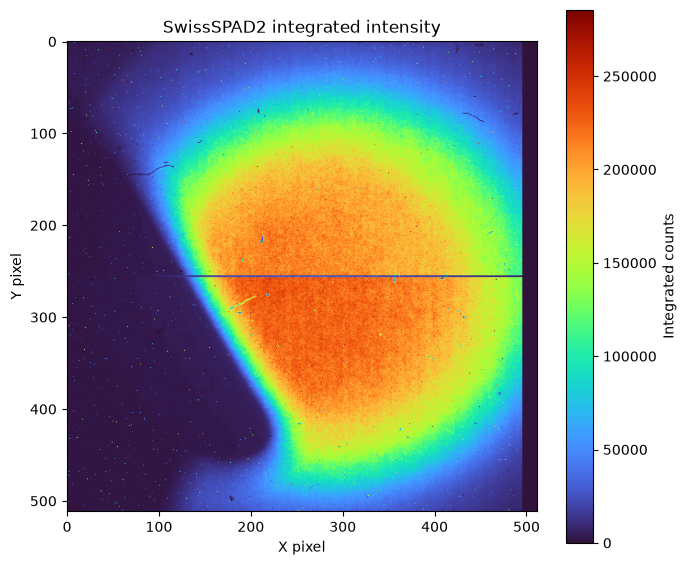

In [6]:
intensity = np.sum(
    decay,
    axis=-1,
    dtype=np.float64,
)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    intensity,
    cmap="turbo",
    origin="upper",
)

fig.colorbar(
    image,
    ax=ax,
    label="Integrated counts",
)

ax.set_title("SwissSPAD2 integrated intensity")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

fig.tight_layout()
plt.show()

## Inspect the temporal response

The spatially integrated temporal response provides a direct view of gate ordering and the overall time-resolved acquisition.

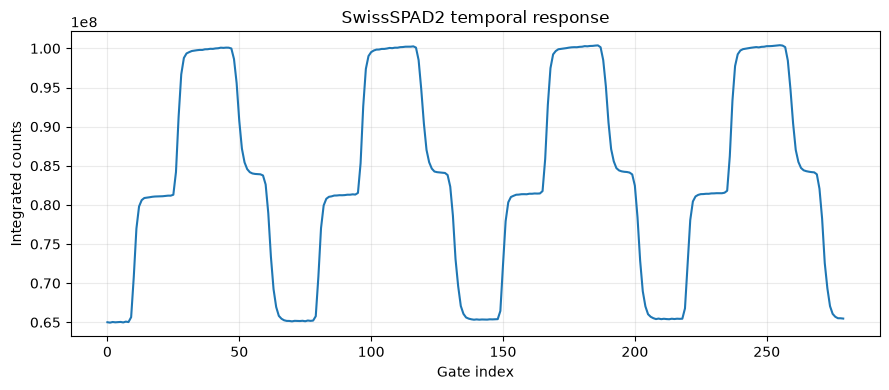

In [7]:
temporal_trace = np.sum(
    decay,
    axis=(0, 1),
    dtype=np.float64,
)

gate_axis = np.arange(decay.shape[-1])

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    gate_axis,
    temporal_trace,
)

ax.set_title("SwissSPAD2 temporal response")
ax.set_xlabel("Gate index")
ax.set_ylabel("Integrated counts")
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Inspect representative gates

Several gates distributed across the acquisition are displayed independently. This provides a direct visual check that the spatial image remains physically consistent across the temporal dimension.

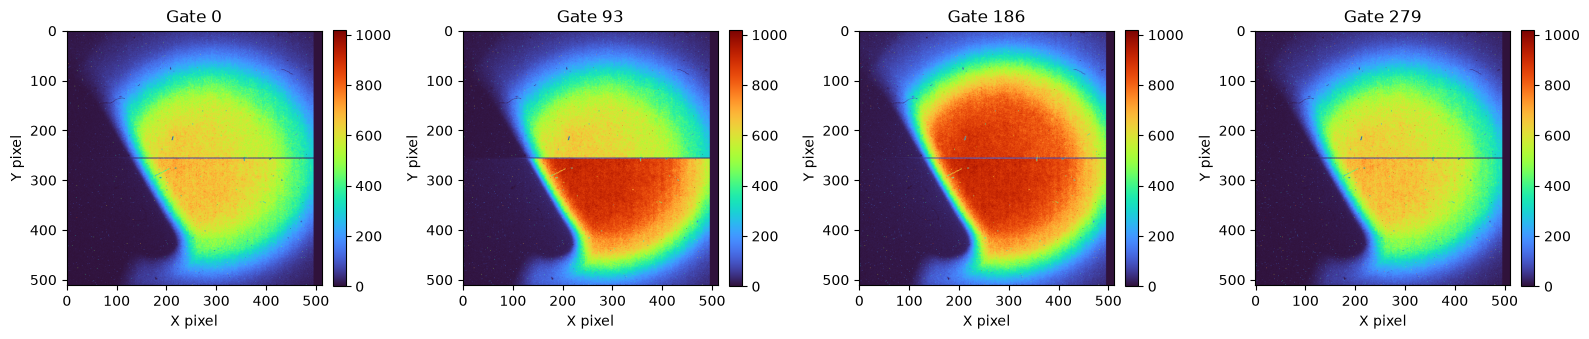

In [8]:
number_of_gate_images = min(
    4,
    decay.shape[-1],
)

gate_indices = np.unique(
    np.linspace(
        0,
        decay.shape[-1] - 1,
        number_of_gate_images,
        dtype=int,
    )
)

fig, axes = plt.subplots(
    1,
    len(gate_indices),
    figsize=(4 * len(gate_indices), 4),
    squeeze=False,
)

for axis, gate_index in zip(
    axes[0],
    gate_indices,
):
    image = axis.imshow(
        decay[..., gate_index],
        cmap="turbo",
        origin="upper",
    )

    axis.set_title(f"Gate {gate_index}")
    axis.set_xlabel("X pixel")
    axis.set_ylabel("Y pixel")

    fig.colorbar(
        image,
        ax=axis,
        fraction=0.046,
        pad=0.04,
    )

fig.tight_layout()
plt.show()

## Validate native binary stitching

Native SwissSPAD2 binary acquisitions are reconstructed from top and bottom detector halves. For binary input, the row-intensity profile is displayed with the detector-half boundary marked between rows 255 and 256.

HDF5 acquisitions do not use this binary stitching step.

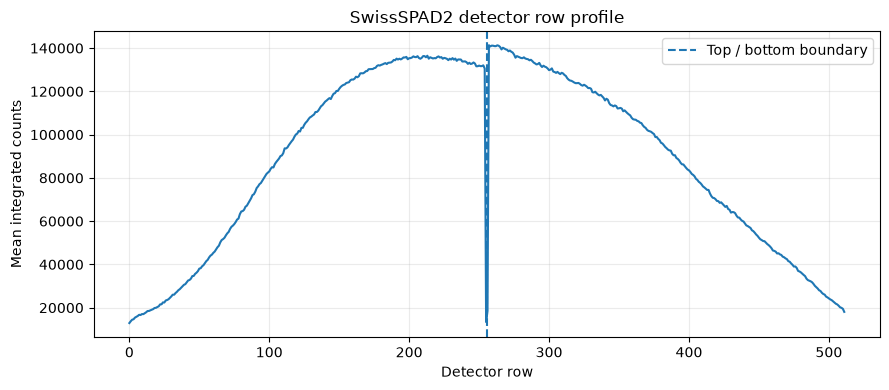

In [9]:
if input_format == "ss2_bin":
    row_profile = np.mean(
        intensity,
        axis=1,
    )

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(
        np.arange(row_profile.size),
        row_profile,
    )

    ax.axvline(
        255.5,
        linestyle="--",
        label="Top / bottom boundary",
    )

    ax.set_title("SwissSPAD2 detector row profile")
    ax.set_xlabel("Detector row")
    ax.set_ylabel("Mean integrated counts")
    ax.legend()
    ax.grid(alpha=0.25)

    fig.tight_layout()
    plt.show()

else:
    print(
        "HDF5 input detected. Native BIN top/bottom stitching is not used "
        "for this acquisition."
    )

## Review import metadata

PyFLI records the resolved input format, raw and output shapes, detector settings, processing state, and lower-level reader metadata with the loaded dataset.

In [10]:
pprint(
    spad_metadata,
    sort_dicts=False,
)

{'source': {'source_format': 'ss2_bin',
            'bit_depth': 10,
            'chunk_indices': (0,),
            'top_files': ('E:\\ss2dataprocess\\raw_data\\bins\\top0.bin',),
            'bottom_files': ('E:\\ss2dataprocess\\raw_data\\bins\\btm0.bin',),
            'raw_frame_count': 1120,
            'gate_count': 280,
            'half_shape': (256, 512),
            'stitched_shape': (512, 512, 280),
            'column_banks': 4,
            'bank_width': 128,
            'raw_dtype': 'uint8',
            'output_dtype': 'uint16',
            'subframes_per_gate': 4,
            'detector': 'ss2'},
 'detector': 'ss2',
 'input_format': 'ss2_bin',
 'raw_shape': (512, 512, 280),
 'raw_dtype': 'uint16',
 'output_shape': (512, 512, 280),
 'output_dtype': 'uint16',
 'bit_depth': 10,
 'hot_pixel_applied': False,
 'hot_pixel_scope': None,
 'pile_up_applied': False,
 'pile_up_scope': None,
 'sub_bg_applied': False,
 'sub_bg_scope': None,
 'fold_applied': False,
 'fold': None,
 'config'

## Summary

The SwissSPAD2 acquisition has now been loaded without detector corrections and validated in its normalized `(H, W, T)` representation.

The next example applies detector-specific processing, including pile-up correction, optional background and hot-pixel correction for HDF5 folder acquisitions, optional temporal folding, masks, and associated metadata inspection.